<!-- notebook:description -->
# Notebook: RQ4 — LLM Comparison

**Rôle**: comparer l'impact du modèle LLM sur les résultats (qualité/cohérence/etc.).

**Objectif**: analyser et visualiser les différences entre modèles à partir des sorties RQ4.

*Notebook basé sur données réelles (dernier rapport JSON RQ4). Pas de simulation.*

## Load latest RQ4 report

<!-- explain-cell -->
### Étape 1
Cette cellule exécute une partie de l'analyse (imports / chargement de données / calculs / visualisations / export)


In [1]:
# --- cell-doc ---
# But: exécuter un bloc de l'analyse sans modifier la logique.
# Entrées: variables définies par les cellules précédentes.
# Sorties: variables/figures/fichiers produits par ce bloc.

import json
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)

REPORT_DIR = Path('../results/rq4')
report_files = sorted(REPORT_DIR.glob('rq4_report_*.json'), key=lambda p: p.stat().st_mtime, reverse=True)
if not report_files:
    raise FileNotFoundError(
        f'No RQ4 report found in {REPORT_DIR.resolve()}. Run experiments/rq4_llm_comparison.py to generate rq4_report_*.json'
    )
REPORT_PATH = report_files[0]
print('Using report:', REPORT_PATH)

report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
report.keys()


Using report: ../results/rq4/rq4_report_httpbin_testing_api_rq4_20251213_041306.json


dict_keys(['experiment_id', 'config', 'started_at', 'completed_at', 'model_results', 'rankings', 'best_models', 'statistical_significance', 'effect_sizes'])

## Model-level results table

<!-- explain-cell -->
### Étape 2
Cette cellule exécute une partie de l'analyse (imports / chargement de données / calculs / visualisations / export)


In [2]:
# --- cell-doc ---
# But: exécuter un bloc de l'analyse sans modifier la logique.
# Entrées: variables définies par les cellules précédentes.
# Sorties: variables/figures/fichiers produits par ce bloc.

def flatten(model_result: dict) -> dict:
    row = {'llm_model': model_result.get('llm_model'), 'overall_score': model_result.get('overall_score')}
    for section in ['oracle_metrics', 'code_quality_metrics', 'consistency_metrics', 'performance_metrics', 'cost_metrics', 'robustness_metrics', 'success_metrics']:
        for k, v in (model_result.get(section) or {}).items():
            row[f'{section}.{k}'] = v
    return row

rows = [flatten(r) for r in (report.get('model_results') or [])]
model_df = pd.DataFrame(rows).sort_values('overall_score', ascending=False)
model_df


,llm_model,overall_score,oracle_metrics.precision,oracle_metrics.recall,oracle_metrics.f1,oracle_metrics.confidence_avg,code_quality_metrics.correctness,code_quality_metrics.readability,code_quality_metrics.maintainability,code_quality_metrics.overall,consistency_metrics.coherence_score,consistency_metrics.java_coverage,consistency_metrics.gherkin_coverage,consistency_metrics.inconsistency_count,performance_metrics.avg_generation_time_ms,performance_metrics.avg_input_tokens,performance_metrics.avg_output_tokens,performance_metrics.total_generation_time_ms,cost_metrics.total_cost_usd,cost_metrics.cost_per_endpoint_usd,cost_metrics.cost_per_test_usd,robustness_metrics.robustness_score,robustness_metrics.quality_degradation_rate,success_metrics.successful_generations,success_metrics.total_attempts,success_metrics.success_rate
0,llama32,0.577339,0.75,0.447917,0.453896,0.575,0.54375,0.9375,1.0,0.79875,0.7,2.8,2.25,2,36410.496444,0.0,0.0,327694.468,0.0,0.0,0.0,0.0,0.0,0,9,0.0


## Visualizations

<!-- explain-cell -->
### Étape 3
Cette cellule exécute une partie de l'analyse (imports / chargement de données / calculs / visualisations / export)


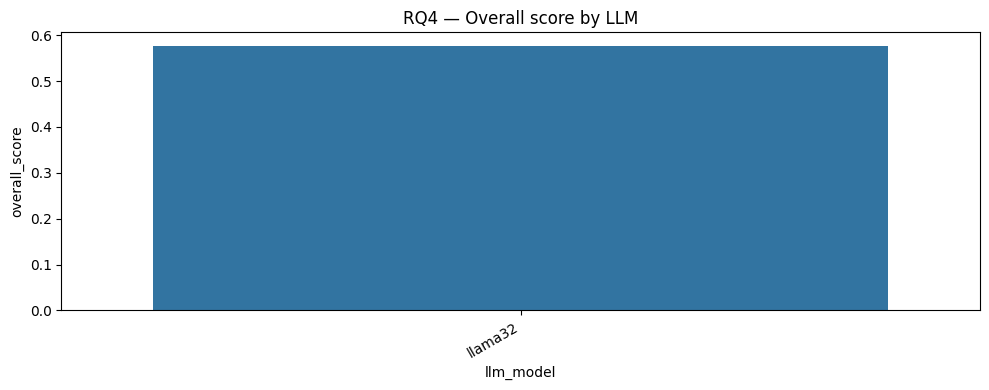

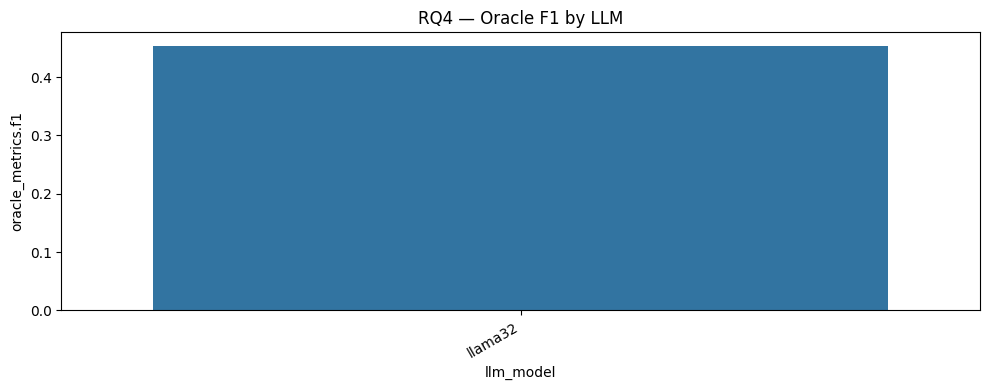

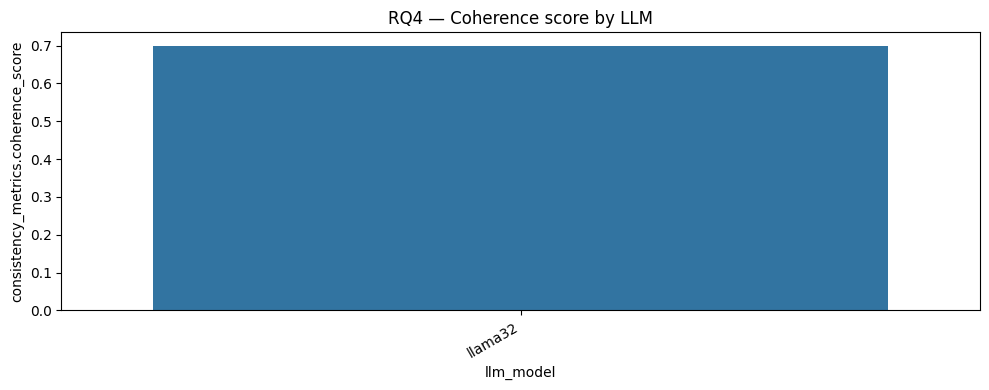

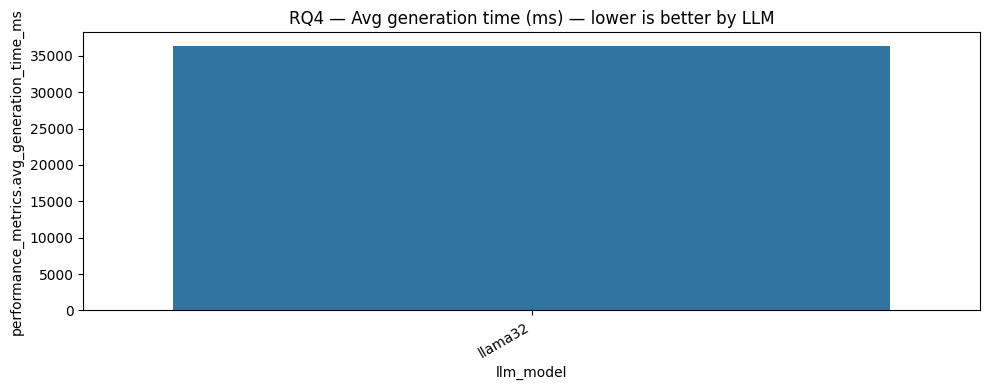

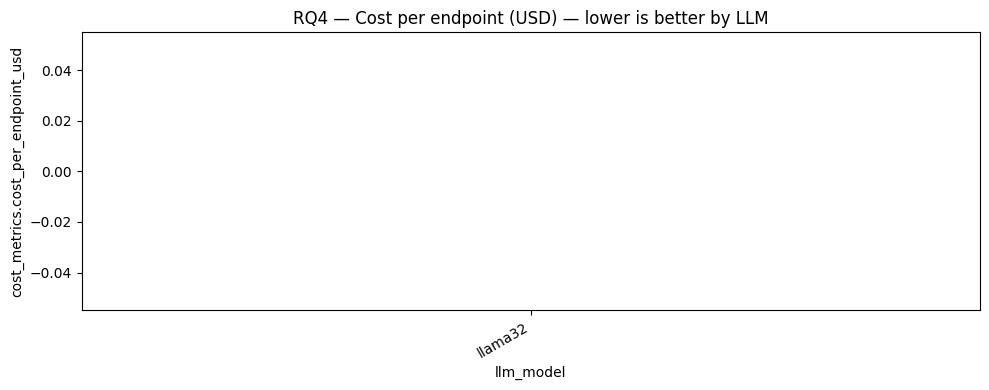

In [3]:
# --- cell-doc ---
# But: exécuter un bloc de l'analyse sans modifier la logique.
# Entrées: variables définies par les cellules précédentes.
# Sorties: variables/figures/fichiers produits par ce bloc.

if model_df.empty:
    raise ValueError('No model_results in report.')

plt.figure(figsize=(10, 4))
sns.barplot(data=model_df, x='llm_model', y='overall_score')
plt.title('RQ4 — Overall score by LLM')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

for col, title in [
    ('oracle_metrics.f1', 'Oracle F1'),
    ('consistency_metrics.coherence_score', 'Coherence score'),
    ('performance_metrics.avg_generation_time_ms', 'Avg generation time (ms) — lower is better'),
    ('cost_metrics.cost_per_endpoint_usd', 'Cost per endpoint (USD) — lower is better'),
]:
    if col in model_df.columns:
        plt.figure(figsize=(10, 4))
        sns.barplot(data=model_df, x='llm_model', y=col)
        plt.title(f'RQ4 — {title} by LLM')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()


## Export

<!-- explain-cell -->
### Étape 4
Cette cellule exécute une partie de l'analyse (imports / chargement de données / calculs / visualisations / export)


In [4]:
# --- cell-doc ---
# But: exécuter un bloc de l'analyse sans modifier la logique.
# Entrées: variables définies par les cellules précédentes.
# Sorties: variables/figures/fichiers produits par ce bloc.

OUT_DIR = Path('./outputs/rq4')
OUT_DIR.mkdir(parents=True, exist_ok=True)

model_df.to_csv(OUT_DIR / 'rq4_model_results.csv', index=False)

summary = {
    'report_path': str(REPORT_PATH),
    'experiment_id': report.get('experiment_id'),
    'best_models': report.get('best_models'),
    'rankings': report.get('rankings'),
}
(OUT_DIR / 'rq4_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Wrote:', OUT_DIR)


Wrote: outputs/rq4
